# ***Importing libraries and The data***

In [234]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt

from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader

import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder

import torch.nn as nn
import torch.nn.functional as F

In [235]:
import kagglehub
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [236]:
data_dir  = '/kaggle/input/garbage-classification/Garbage classification/Garbage classification'

classes = os.listdir(data_dir)
num_classes = len(classes)
print("Total Number of Classes is:",num_classes)
print(classes)

Total Number of Classes is: 6
['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


# ***Transformation***

In [238]:
transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
   ])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    ])

dataset = ImageFolder(data_dir)

In [239]:
def show_img(img, label):
    print("Label:", dataset.classes[label], "(Class No: "+ str(label) + ")")
    plt.imshow(img.permute(1, 2, 0))

Label: paper (Class No: 3)


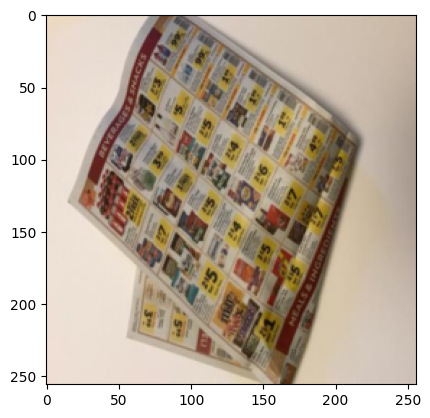

In [240]:
img_pil, label = dataset[1500]
img_tensor = val_test_transform(img_pil)
show_img(img_tensor, label)

# ***Loading and Splitting Data:***

In [241]:
torch.manual_seed(42)

In [242]:
print(f"Total length of dataset: {len(dataset)}")

Total length of dataset: 2527


In [243]:
train_DS, val_DS, test_DS = random_split(dataset, [1593, 176, 758])
len(train_DS), len(val_DS), len(test_DS)

(1593, 176, 758)

In [244]:
train_DS.dataset.transform = transforms
val_DS.dataset.transform   = val_test_transform
test_DS.dataset.transform  = val_test_transform

In [245]:
batch_size = 32
train_DL = DataLoader(train_DS, batch_size, shuffle = True, num_workers = 4, pin_memory = True)
val_DL = DataLoader(val_DS, batch_size*2, num_workers = 4, pin_memory = True)
test_DL = DataLoader(test_DS, batch_size*2, num_workers = 4, pin_memory = True)

# ***Model***

In [246]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [247]:
class ImageClassification(nn.Module):
  def training_step(self, batch):
    images, labels = batch
    output = self(images)
    loss = F.cross_entropy(output, labels)
    _, preds = torch.max(output, dim=1)
    acc = torch.tensor(torch.sum(preds == labels).item() / len(preds))
    return loss, acc

  def validation_step(self, batch):
    images, labels = batch
    output = self(images)
    loss = F.cross_entropy(output, labels)
    acc = accuracy(output, labels)
    return {"val_loss": loss.detach(), "val_acc": acc}

  def validation_epochs(self, outputs):
    batch_loss = [x["val_loss"] for x in outputs]
    epoch_loss = torch.stack(batch_loss).mean()

    batch_acc = [x["val_acc"] for x in outputs]
    epoch_acc = torch.stack(batch_acc).mean()

    return {"val_loss": epoch_loss.item(), "val_acc": epoch_acc.item()}

  def epochs_numbers(self, epoch, result):
    print(f"""Epoch: {epoch+1} Train Loss: {result["train_loss"]:.4f}, Train Accuracy: {result["train_acc"]:.4f},
            Validation Loss: {result["val_loss"]:.4f}, Validation Accuracy: {result["val_acc"]:.4f}""")
    print("="*75)

In [248]:
from torchvision.models import ResNet50_Weights

class ResNet(ImageClassification):
    def __init__(self):
        super().__init__()
        # Use a pretrained model
        self.network = models.resnet50(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, len(dataset.classes))

    def forward(self, xb):
        return self.network(xb)


model = ResNet()

# ***Porting to GPU***

In [249]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [250]:
device = get_default_device()
device

device(type='cuda')

In [251]:
train_dl = DeviceDataLoader(train_DL, device)
val_dl = DeviceDataLoader(val_DL, device)
to_device(model, device)

ResNet(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (

# ***Training the Model***

In [252]:
@torch.no_grad()

def evaluate(model, val_loader):
  model.eval()
  outputs = [model.validation_step(batch) for batch in val_loader]
  return model.validation_epochs(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):

  numbers  = []
  optimizer = opt_func(model.parameters(), lr=lr)

  for epoch in range(epochs):
    model.train()
    train_losses = []
    train_accuracies = []

    for batch in train_loader:
      loss, acc = model.training_step(batch)
      train_losses.append(loss)
      train_accuracies.append(acc)

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    result = evaluate(model, val_loader)
    result["train_loss"] = torch.stack(train_losses).mean().item()
    result["train_acc"] = torch.stack(train_accuracies).mean().item()
    model.epochs_numbers(epoch, result)
    numbers.append(result)
  return numbers

In [253]:
model = to_device(ResNet(), device)

In [254]:
num_epochs = 9
optim_function = torch.optim.Adam
lr = 5.5e-5

history = fit(num_epochs, lr, model, train_dl, val_dl, optim_function)

Epoch: 1 Train Loss: 0.8203, Train Accuracy: 0.7400,
            Validation Loss: 0.3421, Validation Accuracy: 0.9132
Epoch: 2 Train Loss: 0.1889, Train Accuracy: 0.9486,
            Validation Loss: 0.2529, Validation Accuracy: 0.9115
Epoch: 3 Train Loss: 0.0935, Train Accuracy: 0.9765,
            Validation Loss: 0.2480, Validation Accuracy: 0.9323
Epoch: 4 Train Loss: 0.0267, Train Accuracy: 0.9987,
            Validation Loss: 0.1852, Validation Accuracy: 0.9514
Epoch: 5 Train Loss: 0.0172, Train Accuracy: 0.9981,
            Validation Loss: 0.1690, Validation Accuracy: 0.9514
Epoch: 6 Train Loss: 0.0139, Train Accuracy: 0.9981,
            Validation Loss: 0.2013, Validation Accuracy: 0.9462
Epoch: 7 Train Loss: 0.0157, Train Accuracy: 0.9969,
            Validation Loss: 0.1784, Validation Accuracy: 0.9497
Epoch: 8 Train Loss: 0.0166, Train Accuracy: 0.9962,
            Validation Loss: 0.2126, Validation Accuracy: 0.9462
Epoch: 9 Train Loss: 0.0149, Train Accuracy: 0.9975,
   

In [262]:
torch.save(model.state_dict(), "resnet50_garbage_best.pth")

# ***Testing***

In [255]:
test_dl = DeviceDataLoader(test_DL, device)

In [256]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for inputs, labels in test_dl:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = F.cross_entropy(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_DS.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")

Accuracy Score is: 92.6121 and Loss is 0.0032


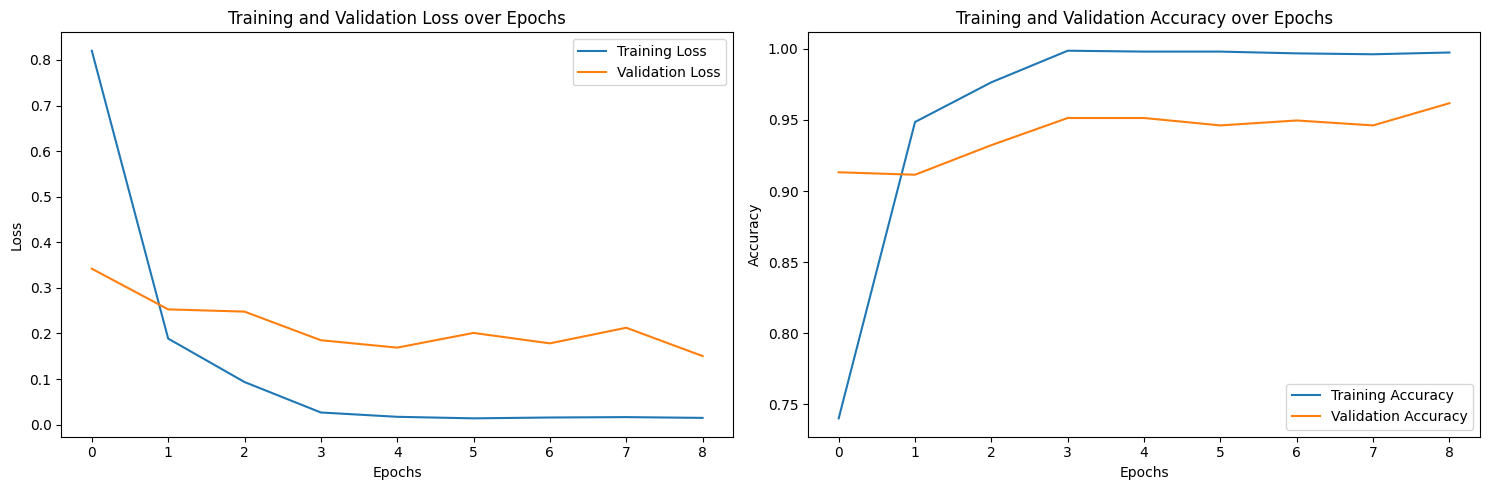

In [313]:
import matplotlib.pyplot as plt

total_loss_train_plot = [x['train_loss'] for x in history]
total_loss_validation_plot = [x['val_loss'] for x in history]
total_acc_train_plot = [x['train_acc'] for x in history]
total_acc_validation_plot = [x['val_acc'] for x in history]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

In [258]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    prob, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return dataset.classes[preds[0].item()]

Label: metal , Predicted: metal


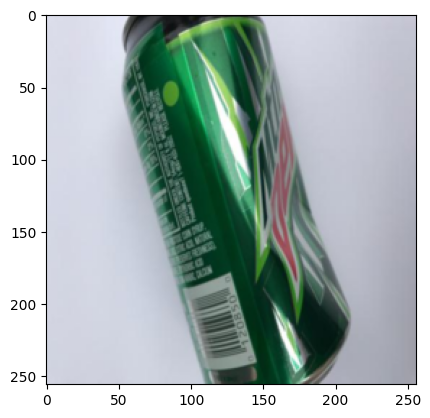

In [284]:
img, label = test_DS[179]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

Label: plastic , Predicted: plastic


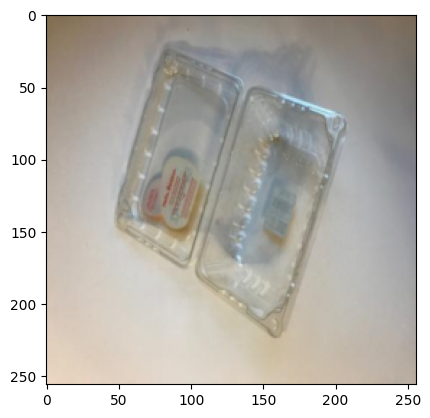

In [260]:
img, label = test_DS[43]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

Label: paper , Predicted: paper


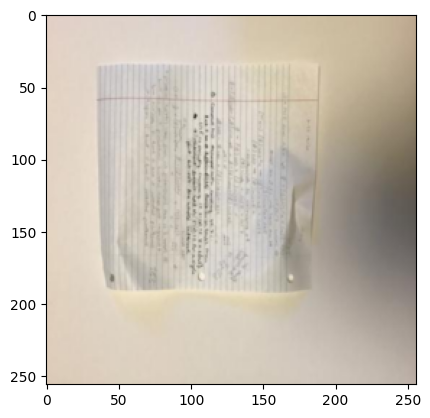

In [281]:
img, label = test_DS[378]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

Label: cardboard , Predicted: cardboard


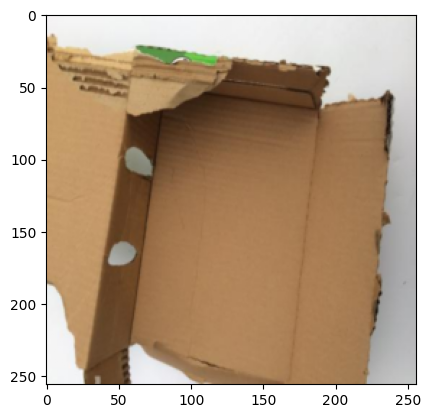

In [278]:
img, label = test_DS[144]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

Label: glass , Predicted: glass


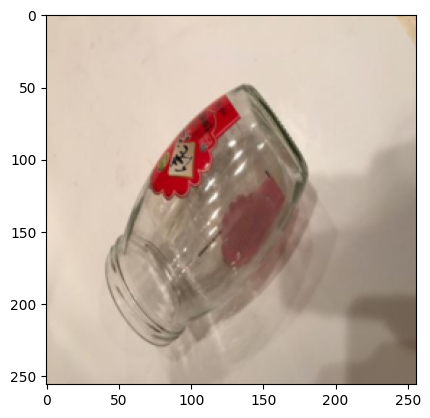

In [286]:
img, label = test_DS[9]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

# ***Performance Summary***

The training process ran for 9 epochs. The model's performance on the training, validation, and test datasets can be summarized as follows:

**Training Performance (Last Epoch):**
- **Loss:** 0.0149
- **Accuracy:** 0.99

**Validation Performance (Last Epoch):**
- **Loss:** 0.1505
- **Accuracy:** 0.96

**Test Performance:**
- **Loss:** 0.0032
- **Accuracy:** 0.93
